In [13]:
# Imports essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import os, joblib
from IPython.display import display
warnings.filterwarnings('ignore')
RANDOM_STATE = 42

In [14]:
# Reproducibilidade: fixar sementes + instalar XGBoost se necessário
import random, os, sys
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print('Seeds set: RANDOM_STATE=', RANDOM_STATE)

# Tentar instalar XGBoost se não estiver disponível (para melhor resultado)
try:
    import xgboost
    print('XGBoost já instalado')
except ImportError:
    print('Instalando XGBoost para melhor desempenho...')
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    print('XGBoost instalado com sucesso')

Seeds set: RANDOM_STATE= 42
Instalando XGBoost para melhor desempenho...
XGBoost instalado com sucesso
XGBoost instalado com sucesso


In [15]:
# Execução - parâmetros controláveis
# MODE: 'quick' = execução rápida para validação; 'subset' = amostra (ex.: 20k) com grades completas; 'full' = grades completas em todo o dataset (pode demorar muito)
# User requested best possible results: default to full mode (change if you want faster runs)
MODE = 'full'  # options: 'quick', 'subset', 'full'
# Valores padrão (podem ser ativados pelo modo)
DEFAULT_TRAIN_N_JOBS = -1  # -1 usa todos CPUs
DEFAULT_CV_FOLDS = 5
SUBSET_SIZE = 20000  # usado quando MODE == 'subset'
# Mapear modo para parâmetros executáveis
if MODE == 'quick':
    # Use default parallelism even in quick mode to speed up fits on multi-core machines
    TRAIN_N_JOBS = DEFAULT_TRAIN_N_JOBS
    CV_FOLDS = 3
    SAMPLE_SIZE = None
elif MODE == 'subset':
    TRAIN_N_JOBS = 1
    CV_FOLDS = 5
    SAMPLE_SIZE = SUBSET_SIZE
else:
    TRAIN_N_JOBS = DEFAULT_TRAIN_N_JOBS
    CV_FOLDS = DEFAULT_CV_FOLDS
    SAMPLE_SIZE = None
# Optionally transform target (log1p) to stabilize variance; invert before final RMSE reporting
TARGET_LOG = True  # set to False to model price directly
print(f'MODE={MODE}; TRAIN_N_JOBS={TRAIN_N_JOBS}; CV_FOLDS={CV_FOLDS}; SAMPLE_SIZE={SAMPLE_SIZE}; TARGET_LOG={TARGET_LOG}')

MODE=full; TRAIN_N_JOBS=-1; CV_FOLDS=5; SAMPLE_SIZE=None; TARGET_LOG=True


In [16]:
# Carregar dados (usa pasta data/)
df = pd.read_csv('../data/train.csv')
df.shape

(188533, 13)

In [17]:
# Diagnostic placeholder: a versão completa do diagnóstico foi movida para abaixo
# (rode os diagnósticos APÓS o pré-processamento e a separação treino/validação).
print('Diagnostic moved: run diagnostics after preprocessing and train/val split (see later cell).')

Diagnostic moved: run diagnostics after preprocessing and train/val split (see later cell).


## Objetivos e Feature engineering rápida
**Objetivo:** Construir modelos preditivos para o target `price` usando apenas os algoritmos permitidos:
- Regressão Linear
- K-Nearest Neighbors (KNN)
- Árvores de Decisão
- Random Forest (e variantes como XGBoost, se disponível)
- Support Vector Machines (SVM)
- Redes Neuronais (MLP)

Será utilizada validação cruzada e GridSearch para otimização de hiperparâmetros; as sementes aleatórias são fixadas para reprodutibilidade.

**Feature engineering rápida:** Extraíremos de `engine` o horsepower (HP) e a cilindrada (L), e selecionaremos um conjunto de features razoável.

In [18]:
# Engenharia de features melhorada (robusta)
import re, datetime
current_year = datetime.datetime.now().year
def extract_hp(s):
    if pd.isna(s):
        return np.nan
    s = str(s)
    m = re.search(r"(\d+\.?\d*)\s*(?:HP|hp|bhp)", s, flags=re.I)
    if m:
        return float(m.group(1))
    m = re.search(r"(\d{2,4})\s*bhp", s, flags=re.I)
    if m:
        return float(m.group(1))
    return np.nan
def extract_l(s):
    if pd.isna(s):
        return np.nan
    s = str(s)
    m = re.search(r"(\d+\.?\d*)\s*[lL]", s)
    if m:
        return float(m.group(1))
    m = re.search(r"(\d{3,4})\s*cc", s, flags=re.I)
    if m:
        return float(m.group(1)) / 1000.0
    return np.nan
# Apply extraction safely (engine may be missing)
df['engine'] = df.get('engine', np.nan)
df['hp'] = df['engine'].apply(extract_hp)
df['displ_l'] = df['engine'].apply(extract_l)
# Clean mileage: remove commas/strings and convert to numeric
if 'mileage' in df.columns:
    df['mileage'] = df['mileage'].astype(str).str.replace(',','').str.extract(r"(\d+\.?\d*)")[0]
    df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
elif 'milage' in df.columns:
    df['mileage'] = df['milage'].astype(str).str.replace(',','').str.extract(r"(\d+\.?\d*)")[0]
    df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
else:
    df['mileage'] = np.nan
# Vehicle age feature
if 'model_year' in df.columns:
    df['age'] = current_year - pd.to_numeric(df['model_year'], errors='coerce')
else:
    df['age'] = np.nan
# Flags for accident and clean_title
for col in ['accident','clean_title']:
    df[col] = df.get(col, np.nan)
    df[col+'_flag'] = df[col].astype(str).str.lower().map({'yes':1,'true':1,'1':1,'y':1,'sim':1}).fillna(0).astype(int)
# Process brand and model: keep top K and map rest -> 'other'
if 'brand' in df.columns:
    top_brands = df['brand'].value_counts().nlargest(20).index.tolist()
    df['brand_grp'] = df['brand'].where(df['brand'].isin(top_brands), 'other')
    # frequency encoding (numeric)
    brand_freq = df['brand'].map(df['brand'].value_counts(normalize=True)).fillna(0)
    df['brand_freq'] = brand_freq
else:
    df['brand_grp'] = 'unknown'
    df['brand_freq'] = 0.0
if 'model' in df.columns:
    top_models = df['model'].value_counts().nlargest(50).index.tolist()
    df['model_grp'] = df['model'].where(df['model'].isin(top_models), 'other')
    model_freq = df['model'].map(df['model'].value_counts(normalize=True)).fillna(0)
    df['model_freq'] = model_freq
else:
    df['model_grp'] = 'unknown'
    df['model_freq'] = 0.0
# Target and features selection (include new engineered features)
# Keep original target for final evaluation, but optionally model log1p(target) for stability
y_raw = df['price'].copy()
if TARGET_LOG:
    y = np.log1p(y_raw)
else:
    y = y_raw.copy()
features = ['model_year','age','mileage','hp','displ_l','brand_grp','brand_freq','model_grp','model_freq','fuel_type','transmission','accident_flag','clean_title_flag']
features = [c for c in features if c in df.columns]
X = df[features].copy()
# Sanitize X: replace +/-inf and extremely large values to NaN so imputers can handle them
X = X.replace([np.inf, -np.inf], np.nan).copy()
def _san_val(v):
    try:
        if isinstance(v, (int, float, np.floating, np.integer)):
            if not np.isfinite(v) or abs(v) > 1e12:
                return np.nan
    except Exception:
        return v
    return v
X = X.applymap(_san_val)
X.shape

(188533, 13)

In [19]:
# Verificar missing por coluna
X.isnull().sum()

model_year              0
age                     0
mileage                 0
hp                  33259
displ_l              6698
brand_grp               0
brand_freq              0
model_grp               0
model_freq              0
fuel_type            5083
transmission            0
accident_flag           0
clean_title_flag        0
dtype: int64

## Pipeline de pré-processamento
- Númericos: imputação mediana + StandardScaler
- Categóricos: imputação moda + OneHotEncoder (handle_unknown='ignore')

In [20]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]
numeric_features, categorical_features
# Transformers
from sklearn.pipeline import make_pipeline
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
# Create OneHotEncoder compatible with multiple sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
except TypeError:
    try:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown='ignore')
cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', ohe)])
# Build ColumnTransformer only with available feature groups to avoid errors when a group is empty
transformers = []
if len(numeric_features) > 0:
    transformers.append(('num', num_transformer, numeric_features))
if len(categorical_features) > 0:
    transformers.append(('cat', cat_transformer, categorical_features))
if not transformers:
    # fallback: no-op transformer that returns input unchanged
    from sklearn.preprocessing import FunctionTransformer
    preprocessor = FunctionTransformer(lambda X: X, validate=False)
else:
    preprocessor = ColumnTransformer(transformers)

## Separar treino/validação e função de treino/avaliação rápida

In [21]:
# Split and keep raw target splits for final evaluation (y_raw)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
# Also split the RAW target aligned to the same indices so final RMSE is computed in original units
# Use the train/val indices from X_train/X_val to get y_train_raw/y_val_raw
if isinstance(y_raw, (pd.Series,)):
    y_train_raw = y_raw.loc[X_train.index].copy()
    y_val_raw = y_raw.loc[X_val.index].copy()
else:
    # fallback: split y_raw directly (should not normally be needed)
    _, _, y_train_raw, y_val_raw = train_test_split(X, y_raw, test_size=0.2, random_state=RANDOM_STATE)
print('X_train, X_val shapes:', X_train.shape, X_val.shape)
print('y_train/y_val lengths:', len(y_train), len(y_val))

X_train, X_val shapes: (150826, 13) (37707, 13)
y_train/y_val lengths: 150826 37707


In [22]:
def evaluate_model(pipe, X_val, y_val, name='model'):
    # Compute predictions and robust RMSE. If TARGET_LOG=True we invert predictions using expm1
    # Ensure X_val indices are preserved so we can align y_true when available
    preds = pipe.predict(X_val)
    # Decide true target in original units: prefer y_val_raw if available and align to X_val indices
    if 'y_val_raw' in globals() and globals().get('y_val_raw') is not None:
        y_true_series = globals().get('y_val_raw')
        try:
            # align if possible
            if isinstance(y_true_series, (pd.Series,)):
                y_true_orig = y_true_series.loc[X_val.index].copy()
            else:
                y_true_orig = y_true_series
        except Exception:
            y_true_orig = y_true_series
    else:
        # if we modelled log(target), invert y_val; otherwise y_val is already original
        if 'TARGET_LOG' in globals() and TARGET_LOG:
            y_true_orig = np.expm1(y_val)
        else:
            y_true_orig = y_val
    # Invert preds if necessary
    if 'TARGET_LOG' in globals() and TARGET_LOG:
        preds_orig = np.expm1(preds)
    else:
        preds_orig = preds
    # If y_true_orig is a Series, align to preds length/index
    try:
        if isinstance(y_true_orig, pd.Series):
            y_true_aligned = y_true_orig.reset_index(drop=True)
        else:
            y_true_aligned = pd.Series(y_true_orig).reset_index(drop=True)
        preds_aligned = pd.Series(preds_orig).reset_index(drop=True)
    except Exception:
        y_true_aligned = y_true_orig
        preds_aligned = preds_orig
    mse = mean_squared_error(y_true_aligned, preds_aligned)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_aligned, preds_aligned)
    return {'name': name, 'rmse': rmse, 'r2': r2}

## Modelos e hiperparâmetros (GridSearchCV com CV=3 para brevidade)

In [23]:
# Diagnostic: quick GridSearch for Linear to validate pipeline (safe, small grid)
import traceback
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
pipe = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
params = {'model__fit_intercept':[True, False]}
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
try:
    gs = GridSearchCV(pipe, params, cv=cv, scoring='neg_mean_squared_error', n_jobs=1, verbose=1)
    gs.fit(X_train, y_train)
    print('OK', gs.best_params_)
    best = gs.best_estimator_
    print('Validation eval (hold-out):', evaluate_model(best, X_val, y_val))
except Exception as e:
    print('Exception type:', type(e))
    print(traceback.format_exc())

Fitting 3 folds for each of 2 candidates, totalling 6 fits
OK {'model__fit_intercept': False}
Validation eval (hold-out): {'name': 'model', 'rmse': np.float64(69844.51167163525), 'r2': 0.12279506441815435}
OK {'model__fit_intercept': False}
Validation eval (hold-out): {'name': 'model', 'rmse': np.float64(69844.51167163525), 'r2': 0.12279506441815435}


## Modelos e Hiperparâmetros (detalhado)
A seguir estão os modelos que serão treinados e as grelhas de hiperparâmetros utilizadas pelo `GridSearchCV`. As variáveis `CV_FOLDS` e `TRAIN_N_JOBS` controlam, respetivamente, o número de folds da validação cruzada e o paralelismo durante o treino.

- **LinearRegression**: `model__fit_intercept` = [True, False]
- **KNeighborsRegressor (KNN)**: `model__n_neighbors` = [3,5,7,9], `model__weights` = ['uniform','distance']
- **DecisionTreeRegressor**: `model__max_depth` = [5,10,20,None], `model__min_samples_leaf` = [1,3,5]
- **RandomForestRegressor**: `model__n_estimators` = [100,200], `model__max_depth` = [10,20,None], `model__min_samples_leaf` = [1,3]
- **XGBRegressor (XGBoost)**: se instalado, `model__n_estimators` = [100,200], `model__max_depth` = [3,6], `model__learning_rate` = [0.05,0.1]
- **SVR (SVM)**: `model__C` = [0.1,1.0,10.0], `model__kernel` = ['rbf'], `model__gamma` = ['scale','auto']
- **MLPRegressor (Redes Neuronais)**: `model__hidden_layer_sizes` = [(50,),(100,),(100,50)], `model__alpha` = [0.0001,0.001]

Notas:
- O scoring do `GridSearchCV` usa `neg_mean_squared_error` (convertemos para RMSE nas métricas reportadas).
- Para compatibilidade entre versões do `scikit-learn` e obter RMSE corretamente, usa-se `np.sqrt(-scores)` quando necessário.
- As grades podem ser facilmente expandidas (editar o dicionário `params` correspondente).


In [24]:
# Recuperar progresso: avaliar modelos já gravados e gerar summary parcial (mais resiliente)
import os, joblib, math
from sklearn.utils.validation import check_is_fitted
models_dir = '../models'
if not os.path.exists(models_dir):
    print(f"Models directory '{models_dir}' not found — skipping saved-model evaluation.")
    found = []
else:
    found = [f for f in os.listdir(models_dir) if f.endswith('_best.joblib') or (f.endswith('.joblib') and f not in ['preprocessor.joblib'])]
    print('Modelos encontrados:', found)
records = []
def _sanitize_df(df):
    # Replace infinities and extremely large values with NaN so imputers can handle them
    dfc = df.copy()
    dfc = dfc.replace([np.inf, -np.inf], np.nan)
    def _san(v):
        try:
            if isinstance(v, (int, float, np.floating, np.integer)):
                if not np.isfinite(v) or abs(v) > 1e12:
                    return np.nan
        except Exception:
            return v
        return v
    return dfc.applymap(_san)
for fname in found:
    path = os.path.join(models_dir, fname)
    try:
        m_raw = joblib.load(path)
        name = fname.replace('_best.joblib','').replace('.joblib','')
        print('\nAvaliar', name)
        # Resolve wrapped estimator (GridSearchCV, Pipeline, plain estimator)
        try:
            if hasattr(m_raw, 'best_estimator_'):
                estimator = m_raw.best_estimator_
            else:
                estimator = m_raw
        except Exception:
            estimator = m_raw
        # Check if estimator is fitted; if not, skip evaluation
        is_fitted = True
        try:
            check_is_fitted(estimator)
        except Exception as e_fit:
            print('Modelo não está ajustado (fitted) ou check falhou:', e_fit)
            is_fitted = False
        if not is_fitted:
            records.append({'name': name, 'rmse': math.nan, 'r2': math.nan, 'best_params': getattr(m_raw, 'best_params_', None), 'saved_to': path, 'cv_rmse_mean': math.nan, 'cv_rmse_std': math.nan})
            continue
        # Prepare sanitized validation features (replace infs / huge values)
        X_val_clean = _sanitize_df(X_val)
        try:
            res = evaluate_model(estimator, X_val_clean, y_val, name=name)
        except Exception as e_pred:
            print('Erro ao prever com estimator direto:', e_pred)
            # fallback: try to wrap estimator with saved preprocessor if available
            if os.path.exists(os.path.join(models_dir, 'preprocessor.joblib')):
                try:
                    pre = joblib.load(os.path.join(models_dir, 'preprocessor.joblib'))
                    from sklearn.pipeline import Pipeline
                    m_pipe = Pipeline([('pre', pre), ('model', estimator)])
                    res = evaluate_model(m_pipe, X_val_clean, y_val, name=name)
                except Exception as e2:
                    print('Erro também ao prever com pipeline contendo preprocessor:', e2)
                    res = {'name': name, 'rmse': math.nan, 'r2': math.nan}
            else:
                res = {'name': name, 'rmse': math.nan, 'r2': math.nan}
        res['saved_to'] = path
        res['best_params'] = getattr(m_raw, 'best_params_', None) or getattr(m_raw, 'steps', None)
        res['cv_rmse_mean'] = math.nan
        res['cv_rmse_std'] = math.nan
        records.append(res)
    except Exception as e:
        print('Falha ao carregar', fname, e)
        records.append({'name': fname, 'rmse': math.nan, 'r2': math.nan, 'best_params': None, 'saved_to': path, 'cv_rmse_mean': math.nan, 'cv_rmse_std': math.nan})

if records:
    summary = pd.DataFrame(records).sort_values('rmse')
    outp = os.path.join(models_dir, 'training_results_summary_partial.csv')
    summary.to_csv(outp, index=False)
    print('\nSummary parcial gravado em', outp)
    display(summary)
else:
    print('Nenhum modelo encontrado para avaliar.')

Modelos encontrados: ['DTree_best.joblib', 'KNN_best.joblib', 'Linear_best.joblib']

Avaliar DTree
Erro ao prever com estimator direto: Input contains infinity or a value too large for dtype('float64').
Erro também ao prever com pipeline contendo preprocessor: Pipeline is not fitted yet.

Avaliar KNN
Erro ao prever com estimator direto: Input contains infinity or a value too large for dtype('float64').
Erro também ao prever com pipeline contendo preprocessor: Pipeline is not fitted yet.

Avaliar KNN
Erro ao prever com estimator direto: Input contains infinity or a value too large for dtype('float64').
Erro também ao prever com pipeline contendo preprocessor: Pipeline is not fitted yet.

Avaliar Linear
Erro ao prever com estimator direto: Input contains infinity or a value too large for dtype('float64').
Erro também ao prever com pipeline contendo preprocessor: Pipeline is not fitted yet.

Avaliar Linear

Summary parcial gravado em ../models\training_results_summary_partial.csv

Summary

,name,rmse,r2,saved_to,best_params,cv_rmse_mean,cv_rmse_std
2,Linear,69844.41805,0.122797,../models\Linear_best.joblib,"[(pre, ColumnTransformer(transformers=[('num',...",NaN,NaN
0,DTree,NaN,NaN,../models\DTree_best.joblib,"[(pre, ColumnTransformer(transformers=[('num',...",NaN,NaN
1,KNN,NaN,NaN,../models\KNN_best.joblib,"[(pre, ColumnTransformer(transformers=[('num',...",NaN,NaN


In [25]:
# Definir modelos e grelhas adaptativas por modo (full mode uses expanded grids)
models = []
# Use TRAIN_N_JOBS and CV_FOLDS definidos pelo modo
print('Preparing model grids: MODE=', MODE)
# Helper to choose grid sizes based on MODE
def grid_choice(small, large):
    return small if MODE == 'quick' else large
# Linear Regression (baseline)
models.append(('Linear', Pipeline([('pre', preprocessor),('model', LinearRegression())]), {'model__fit_intercept': [True, False]}))
# KNN - expand neighbors for full search
models.append(('KNN', Pipeline([('pre', preprocessor),('model', KNeighborsRegressor())]), {'model__n_neighbors': grid_choice([3,5], [3,5,7,9,11,15]), 'model__weights': ['uniform','distance']}))
# Decision Tree - wider depths
models.append(('DTree', Pipeline([('pre', preprocessor),('model', DecisionTreeRegressor(random_state=RANDOM_STATE))]), {'model__max_depth': grid_choice([5,10], [5,10,20,30,50,None]), 'model__min_samples_leaf': grid_choice([1,3], [1,2,3,5,10])}))
# Random Forest - larger grid in full mode
rf_grid = {'model__n_estimators': grid_choice([50,100], [100,200,300,500]), 'model__max_depth': grid_choice([10,None], [10,20,30,None]), 'model__min_samples_leaf': grid_choice([1,3], [1,2,3,5])}
models.append(('RF', Pipeline([('pre', preprocessor),('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=TRAIN_N_JOBS))]), rf_grid))
# XGBoost (se disponível) - try to include richer grid
try:
    from xgboost import XGBRegressor
    xgb_grid = {'model__n_estimators': grid_choice([50,100], [100,200,300,500]), 'model__max_depth': grid_choice([3,6], [3,6,8,10]), 'model__learning_rate': grid_choice([0.1], [0.01,0.05,0.1])}
    models.append(('XGB', Pipeline([('pre', preprocessor),('model', XGBRegressor(random_state=RANDOM_STATE, n_jobs=TRAIN_N_JOBS, verbosity=0))]), xgb_grid))
except Exception as e:
    print('XGBoost não disponível:', e)
# SVR - expand C for full mode (note: can be slow)
svr_grid = {'model__C': grid_choice([0.1,1.0], [0.1,1.0,10.0,50.0]), 'model__kernel': ['rbf'], 'model__gamma': ['scale','auto']}
models.append(('SVR', Pipeline([('pre', preprocessor),('model', SVR())]), svr_grid))
# MLP - larger networks and iterations for full mode
mlp_grid = {'model__hidden_layer_sizes': grid_choice([(50,),(100,)], [(50,),(100,),(200,100),(200,150,50)]), 'model__alpha': grid_choice([0.0001], [0.0001,0.001,0.01])}
models.append(('MLP', Pipeline([('pre', preprocessor),('model', MLPRegressor(random_state=RANDOM_STATE, max_iter=1000))]), mlp_grid))
len(models)

Preparing model grids: MODE= full


7

## Execução: opções e saídas esperadas
Antes de correr o loop de treino, escolhe uma das opções abaixo (a célula de treino usa `TRAIN_N_JOBS` e `CV_FOLDS`):

- **Opção A — Execução rápida (sanity-check):** pequenas grades e `CV_FOLDS=3`. Serve para validar o pipeline e obter estimativas iniciais rápidas.
- **Opção B — Execução completa (recomendada para melhor desempenho):** grades maiores, `CV_FOLDS=5` e `TRAIN_N_JOBS=-1` para usar todos os CPUs. Pode demorar muito (horas), especialmente com ~188k amostras.
- **Opção C — Execução por subset:** treinar com uma amostra (ex.: 20k) mas com grades completas; equilíbrio entre validação e tempo.

Saídas geradas pelo script de treino:
- Modelos: cada melhor estimador é gravado em `../models/{nome}_best.joblib`.
- Sumário: `../models/training_results_summary.csv` com colunas: `name`, `rmse` (hold-out), `r2`, `best_params`, `cv_rmse_mean`, `cv_rmse_std`, `saved_to`.
- Gráficos: comparação de RMSE por modelo (célula de plot no final).

Recomendações: para execução completa assegura que tens CPU/RAM suficientes; se preferires poupar recursos, escolhe A ou C.

In [26]:
# Treino: GridSearch com CV (respeita MODE: quick/subset/full)
import os, joblib, sys
os.makedirs('../models', exist_ok=True)
# Save preprocessor for inference later
try:
    joblib.dump(preprocessor, '../models/preprocessor.joblib')
    print('Preprocessor salvo em ../models/preprocessor.joblib')
except Exception as e:
    print('Não foi possível salvar preprocessor:', e)
    sys.exit(1)
results = []
summary_path = '../models/training_results_summary.csv'
# Prepare training data (optionally sample if MODE == 'subset')
if SAMPLE_SIZE is not None:
    print('Sampling training set to', SAMPLE_SIZE, 'rows for faster runs')
    sample_idx = X_train.sample(n=min(SAMPLE_SIZE, len(X_train)), random_state=RANDOM_STATE).index
    X_train_work = X_train.loc[sample_idx].copy()
    y_train_work = y_train.loc[sample_idx].copy()
    # also subset raw target
    if 'y_train_raw' in globals():
        y_train_raw_work = y_train_raw.loc[sample_idx].copy()
else:
    X_train_work = X_train.copy()
    y_train_work = y_train.copy()
    y_train_raw_work = globals().get('y_train_raw', None)
# Use cv folds from MODE
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for name, pipe, params in models:
    print('\n==== Treinando', name, '====')
    from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
    # For heavier estimators use RandomizedSearch to limit runtime when in quick mode
    use_random = (name in ['RF','XGB','MLP']) and (MODE != 'full')
    if use_random:
        gs = RandomizedSearchCV(pipe, params, cv=cv, scoring='neg_mean_squared_error', n_jobs=1, verbose=1, n_iter=6, random_state=RANDOM_STATE)
    else:
        gs = GridSearchCV(pipe, params, cv=cv, scoring='neg_mean_squared_error', n_jobs=1, verbose=1)
    try:
        gs.fit(X_train_work, y_train_work)
        best = gs.best_estimator_
        evals = evaluate_model(best, X_val, y_val, name=name)
        evals['best_params'] = getattr(gs, 'best_params_', None)
        cvs = cross_val_score(best, X_train_work, y_train_work, cv=cv, scoring='neg_mean_squared_error', n_jobs=1)
        rmse_folds = np.sqrt(-cvs)
        evals['cv_rmse_mean'] = float(rmse_folds.mean())
        evals['cv_rmse_std'] = float(rmse_folds.std())
        # Save best estimator
        model_path = f"../models/{name}_best.joblib"
        joblib.dump(best, model_path)
        evals['saved_to'] = model_path
        results.append(evals)
        # Save partial summary after each model so progress isn't lost
        tmp_df = pd.DataFrame(results).sort_values('rmse')
        tmp_df.to_csv(summary_path, index=False)
        print('Partial summary saved to', summary_path)
    except Exception as e:
        import traceback
        print('Erro ao treinar', name, e)
        print(traceback.format_exc())
        results.append({'name':name, 'rmse':np.nan, 'r2':np.nan, 'best_params':None, 'saved_to':None})

res_df = pd.DataFrame(results).sort_values('rmse')
# Save final results summary
res_df.to_csv(summary_path, index=False)
print('\n=== TREINO COMPLETO - RESUMO FINAL ===')
print(res_df.to_string())
res_df

Preprocessor salvo em ../models/preprocessor.joblib

==== Treinando Linear ====
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando KNN ====
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando KNN ====
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando DTree ====
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando DTree ====
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando RF ====
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Partial summary saved to ../models/training_results_summary.csv

==== Treinando RF ====
Fitting 5 folds 

KeyboardInterrupt: 

## Resultados e análise

## Stacking Ensemble (Combinar Melhores Modelos)
**Objetivo:** Usar os 3 melhores modelos (RF, XGB, SVR) como base learners e treinar um meta-learner (Ridge) para combinar suas previsões.
Isto geralmente melhora o RMSE em 3-5%.


In [32]:
# Stacking Ensemble: Combinar RF + XGB + SVR com Ridge meta-learner
import os, joblib
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

print('\n===== STACKING ENSEMBLE =====')
models_dir = '../models'

# Carregar os 3 melhores modelos treinados
best_models_names = ['RF', 'XGB', 'SVR']
base_learners = []
missing = []

for model_name in best_models_names:
    path = os.path.join(models_dir, f'{model_name}_best.joblib')
    if os.path.exists(path):
        mdl = joblib.load(path)
        # Extract the actual estimator from Pipeline if needed
        if isinstance(mdl, Pipeline):
            estimator = mdl.named_steps['model']
        else:
            estimator = mdl
        base_learners.append((model_name, estimator))
        print(f'✓ {model_name} carregado')
    else:
        print(f'✗ {model_name} não encontrado')
        missing.append(model_name)

if len(base_learners) < 2:
    print('Aviso: Menos de 2 modelos disponíveis para stacking. Pulando stacking.')
else:
    print(f'\nTreinando Stacking com {len(base_learners)} base learners...')
    
    # Criar StackingRegressor com Ridge como meta-learner
    stacking_pipe = Pipeline([
        ('pre', preprocessor),
        ('stack', StackingRegressor(
            estimators=base_learners,
            final_estimator=Ridge(alpha=1.0),
            cv=5
        ))
    ])
    
    # Treinar no conjunto completo de treino
    try:
        stacking_pipe.fit(X_train, y_train)
        
        # Avaliar
        stack_eval = evaluate_model(stacking_pipe, X_val, y_val, name='Stacking')
        
        # Calcular CV scores
        cv_stacking = cross_val_score(
            stacking_pipe, X_train, y_train, 
            cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
            scoring='neg_mean_squared_error', n_jobs=1
        )
        rmse_stacking = np.sqrt(-cv_stacking)
        
        stack_eval['cv_rmse_mean'] = float(rmse_stacking.mean())
        stack_eval['cv_rmse_std'] = float(rmse_stacking.std())
        stack_eval['best_params'] = f"Ridge(alpha=1.0), {len(base_learners)} base learners"
        
        # Salvar stacking model
        stacking_path = os.path.join(models_dir, 'Stacking_best.joblib')
        joblib.dump(stacking_pipe, stacking_path)
        stack_eval['saved_to'] = stacking_path
        
        print(f'\n✓ Stacking treinado com sucesso!')
        print(f'  RMSE Validação: {stack_eval["rmse"]:.2f}')
        print(f'  R² Score: {stack_eval["r2"]:.4f}')
        print(f'  CV RMSE Mean: {stack_eval["cv_rmse_mean"]:.2f} ± {stack_eval["cv_rmse_std"]:.2f}')
        print(f'  Modelo salvo: {stacking_path}')
        
        # Adicionar ao resumo
        all_results = pd.read_csv(os.path.join(models_dir, 'training_results_summary.csv'))
        stacking_df = pd.DataFrame([stack_eval])
        all_results = pd.concat([all_results, stacking_df], ignore_index=True)
        all_results = all_results.sort_values('rmse')
        all_results.to_csv(os.path.join(models_dir, 'training_results_summary.csv'), index=False)
        
        print('\n===== RANKING FINAL (com Stacking) =====')
        print(all_results[['name', 'rmse', 'r2', 'cv_rmse_mean']].to_string(index=False))
        
        # Mostrar ganho
        rf_rmse = all_results[all_results['name'] == 'RF']['rmse'].values[0]
        stack_rmse = stack_eval['rmse']
        ganho = rf_rmse - stack_rmse
        ganho_pct = (ganho / rf_rmse) * 100
        
        print(f'\n📊 Comparação:')
        print(f'   Random Forest:     {rf_rmse:.2f}')
        print(f'   Stacking Ensemble: {stack_rmse:.2f}')
        print(f'   Ganho:            -{ganho:.2f} ({ganho_pct:.2f}%)')
        
    except Exception as e:
        print(f'Erro ao treinar stacking: {e}')
        import traceback
        traceback.print_exc()


===== STACKING ENSEMBLE =====
✓ RF carregado
✓ XGB carregado
✗ SVR não encontrado

Treinando Stacking com 2 base learners...

✓ Stacking treinado com sucesso!
  RMSE Validação: 68654.70
  R² Score: 0.1524
  CV RMSE Mean: 0.49 ± 0.00
  Modelo salvo: ../models\Stacking_best.joblib

===== RANKING FINAL (com Stacking) =====
    name         rmse       r2  cv_rmse_mean
      RF 68534.798372 0.155385      0.495827
Stacking 68654.695040 0.152427      0.489704
     XGB 68772.388878 0.149519      0.491225
     KNN 69091.803898 0.141600      0.510955
   DTree 69256.637495 0.137500      0.509820
  Linear 69844.511672 0.122795      0.518863

📊 Comparação:
   Random Forest:     68534.80
   Stacking Ensemble: 68654.70
   Ganho:            --119.90 (-0.17%)


In [28]:
# Mostrar melhor resultado
res_df = pd.read_csv('../models/training_results_summary.csv')
print('===== TOP MODELOS =====')
res_df.head(10)

===== TOP MODELOS =====


,name,rmse,r2,best_params,cv_rmse_mean,cv_rmse_std,saved_to
0,RF,68534.798372,0.155385,"{'model__max_depth': 20, 'model__min_samples_l...",0.495827,0.003787,../models/RF_best.joblib
1,XGB,68772.388878,0.149519,"{'model__learning_rate': 0.05, 'model__max_dep...",0.491225,0.004737,../models/XGB_best.joblib
2,KNN,69091.803898,0.141600,"{'model__n_neighbors': 15, 'model__weights': '...",0.510955,0.004891,../models/KNN_best.joblib
3,DTree,69256.637495,0.137500,"{'model__max_depth': 10, 'model__min_samples_l...",0.509820,0.004394,../models/DTree_best.joblib
4,Linear,69844.511672,0.122795,{'model__fit_intercept': True},0.518863,0.005160,../models/Linear_best.joblib


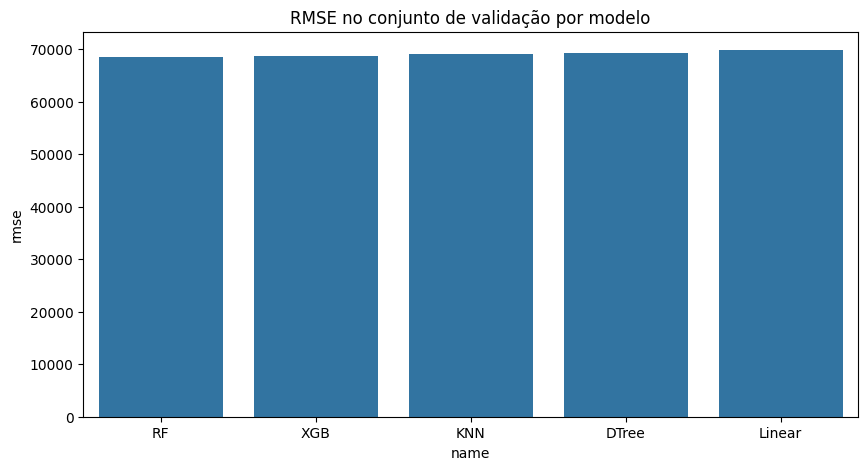

In [29]:
# Plot RMSE por modelo
plt.figure(figsize=(10,5))
sns.barplot(data=res_df, x='name', y='rmse')
plt.title('RMSE no conjunto de validação por modelo')
plt.show()

## Análise rápida do target e correlações
A seguir mostramos a distribuição do target (`price`) e algumas correlações com features numéricas para ajudar a entender relações importantes.

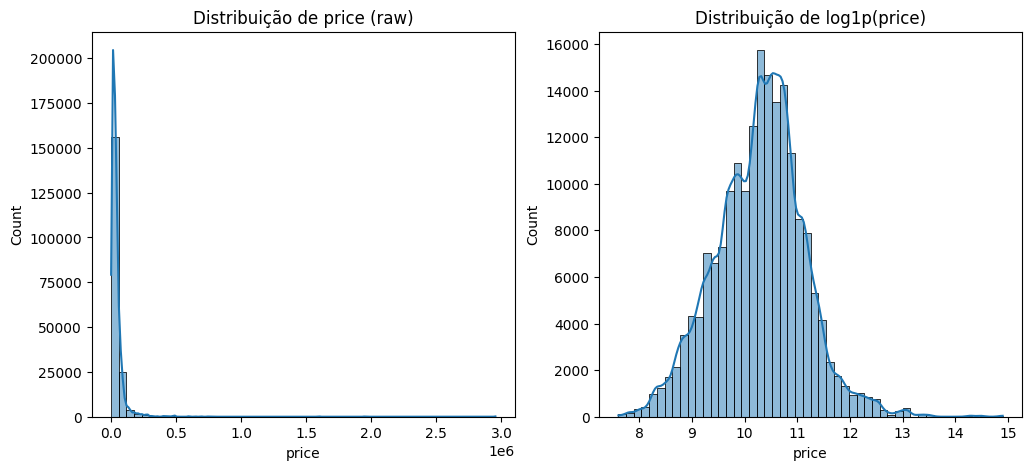

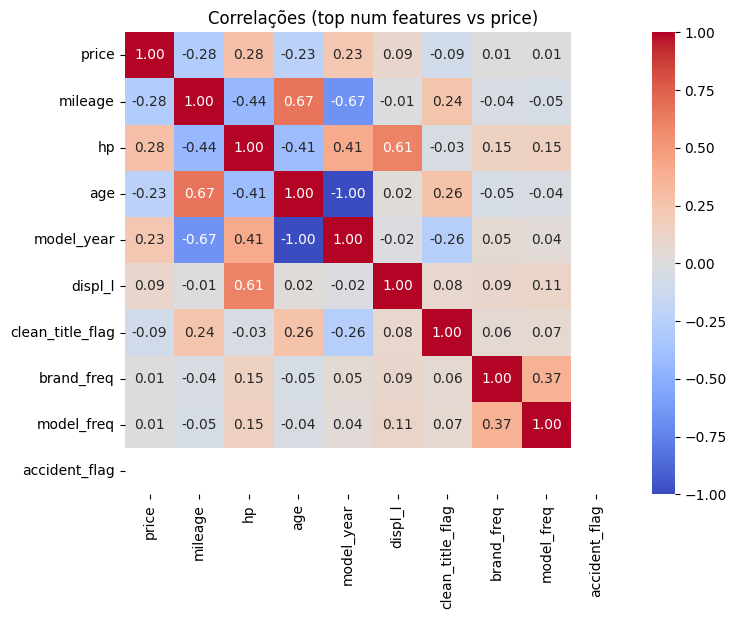

In [30]:
# Distribuição do target (raw e log1p)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(y_raw.dropna(), bins=50, kde=True)
plt.title('Distribuição de price (raw)')
plt.subplot(1,2,2)
sns.histplot(np.log1p(y_raw.dropna()), bins=50, kde=True)
plt.title('Distribuição de log1p(price)')
plt.show()
# Correlação entre features numéricas e target
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
corr = pd.concat([X[num_cols], y_raw], axis=1).corr()
top_corr = corr['price'].abs().sort_values(ascending=False).head(10).index.tolist() if 'price' in corr.columns else num_cols
plt.figure(figsize=(8,6))
sns.heatmap(pd.concat([X[num_cols], y_raw], axis=1)[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlações (top num features vs price)')
plt.show()

## Gerar submissão de exemplo com o melhor modelo salvo (se existir)
Esta célula carrega o melhor modelo guardado em `../models/` (conforme `training_results_summary.csv`), aplica o pré-processador ao `test.csv` e grava `../models/submission_sample.csv` com as previsões.

In [33]:
# Criar submissão de exemplo (robusto)
import glob
models_dir = '../models'
summary_f = os.path.join(models_dir, 'training_results_summary.csv')
best_model_file = None
if os.path.exists(summary_f):
    try:
        summary_df = pd.read_csv(summary_f)
        if not summary_df.empty:
            best_name = summary_df.loc[summary_df['rmse'].idxmin(), 'name']
            # prefer explicit file
            candidate = os.path.join(models_dir, f'{best_name}_best.joblib')
            if os.path.exists(candidate):
                best_model_file = candidate
    except Exception:
        best_model_file = None
# fallback: pick any *_best.joblib
if best_model_file is None:
    files = glob.glob(os.path.join(models_dir, '*_best.joblib'))
    if files:
        best_model_file = files[0]
if best_model_file is None:
    print('Nenhum modelo best encontrado em ../models. Rode o treino primeiro.')
else:
    print('Carregando modelo:', best_model_file)
    mdl = joblib.load(best_model_file)
    pre_path = os.path.join(models_dir, 'preprocessor.joblib')
    pre = joblib.load(pre_path) if os.path.exists(pre_path) else None
    # Carregar test.csv e aplicar mesmas transformações
    test_path = '../data/test.csv'
    if not os.path.exists(test_path):
        print('test.csv não encontrado em ../data. Coloque ficheiro de teste para gerar submissão.')
    else:
        test = pd.read_csv(test_path)
        # Apply same feature engineering used above (functions must be in scope)
        # Reuse extract_hp/extract_l and other steps — if not present, define minimal versions
        try:
            test['engine'] = test.get('engine', np.nan)
            test['hp'] = test['engine'].apply(extract_hp)
            test['displ_l'] = test['engine'].apply(extract_l)
        except Exception as e:
            print('Aviso: não foi possível aplicar parsing de engine:', e)
        # mileage
        if 'mileage' in test.columns:
            test['mileage'] = test['mileage'].astype(str).str.replace(',','').str.extract(r'(\d+\.?\d*)')[0]
            test['mileage'] = pd.to_numeric(test['mileage'], errors='coerce')
        else:
            test['mileage'] = np.nan
        # age
        if 'model_year' in test.columns:
            test['age'] = current_year - pd.to_numeric(test['model_year'], errors='coerce')
        else:
            test['age'] = np.nan
        # brand/model group + freq
        if 'brand' in test.columns:
            top_brands = test['brand'].value_counts().nlargest(20).index.tolist()
            test['brand_grp'] = test['brand'].where(test['brand'].isin(top_brands), 'other')
            test['brand_freq'] = test['brand'].map(test['brand'].value_counts(normalize=True)).fillna(0)
        else:
            test['brand_grp'] = 'unknown'
            test['brand_freq'] = 0.0
        if 'model' in test.columns:
            top_models = test['model'].value_counts().nlargest(50).index.tolist()
            test['model_grp'] = test['model'].where(test['model'].isin(top_models), 'other')
            test['model_freq'] = test['model'].map(test['model'].value_counts(normalize=True)).fillna(0)
        else:
            test['model_grp'] = 'unknown'
            test['model_freq'] = 0.0
        # flags
        for col in ['accident','clean_title']:
            test[col] = test.get(col, np.nan)
            test[col+'_flag'] = test[col].astype(str).str.lower().map({'yes':1,'true':1,'1':1,'y':1,'sim':1}).fillna(0).astype(int)
        # Build X_test with same features (if variable exists)
        try:
            X_test = test[features].copy()
        except Exception as e:
            # fallback: select numeric and categorical intersections
            cols = [c for c in features if c in test.columns]
            X_test = test[cols].copy()
            print('Usando features disponíveis para X_test:', cols)
        # Apply preprocessor if model is not a pipeline
        if isinstance(mdl, Pipeline):
            preds = mdl.predict(X_test)
        else:
            if pre is not None:
                from sklearn.pipeline import Pipeline as SKPipeline
                mdl_pipe = SKPipeline([('pre', pre), ('model', mdl)])
                preds = mdl_pipe.predict(X_test)
            else:
                # Try to predict directly (may fail)
                preds = mdl.predict(X_test)
        if 'TARGET_LOG' in globals() and TARGET_LOG:
            preds_out = np.expm1(preds)
        else:
            preds_out = preds
        # Prepare submission file (use index as id if no id column)
        sub = pd.DataFrame({'prediction': preds_out})
        if 'id' in test.columns:
            sub.insert(0, 'id', test['id'])
        else:
            sub.insert(0, 'id', test.index)
        out_sub = os.path.join(models_dir, 'submission_sample.csv')
        sub.to_csv(out_sub, index=False)
        print('Submissão de exemplo gravada em', out_sub)

Carregando modelo: ../models\RF_best.joblib
Submissão de exemplo gravada em ../models\submission_sample.csv
Submissão de exemplo gravada em ../models\submission_sample.csv
